In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

In [2]:
arquivo = files.upload()

Saving img2.png to img2.png


In [3]:
def quantize_bits(img_array, bits=3):
    shift = 8 - bits
    mask = (0xFF << shift) & 0xFF
    quantized = (img_array.astype(np.uint8) & mask)
    return quantized

In [4]:
img_bgr = cv2.imread('img2.png')
img_bgr

array([[[71, 72, 77],
        [71, 72, 77],
        [71, 72, 77],
        ...,
        [86, 88, 90],
        [86, 88, 90],
        [86, 88, 90]],

       [[66, 66, 71],
        [66, 66, 71],
        [66, 66, 71],
        ...,
        [79, 81, 83],
        [79, 81, 83],
        [79, 81, 83]],

       [[57, 58, 63],
        [57, 58, 63],
        [57, 58, 63],
        ...,
        [75, 76, 78],
        [75, 76, 78],
        [75, 76, 78]],

       ...,

       [[51, 43, 26],
        [53, 42, 26],
        [56, 43, 27],
        ...,
        [28, 72, 78],
        [28, 72, 78],
        [28, 72, 78]],

       [[51, 43, 26],
        [53, 42, 26],
        [56, 43, 27],
        ...,
        [28, 72, 78],
        [28, 72, 78],
        [28, 72, 78]],

       [[51, 43, 26],
        [53, 42, 26],
        [56, 43, 27],
        ...,
        [28, 72, 78],
        [28, 72, 78],
        [28, 72, 78]]], dtype=uint8)

In [6]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

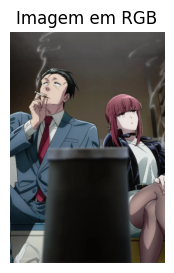

In [7]:
plt.figure(figsize=(5,3)) #cria um quadro 500x300
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Imagem em RGB')
plt.show()

In [8]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

In [9]:
img_gray

array([[73, 73, 73, ..., 88, 88, 88],
       [67, 67, 67, ..., 81, 81, 81],
       [59, 59, 59, ..., 76, 76, 76],
       ...,
       [39, 38, 40, ..., 69, 69, 69],
       [39, 38, 40, ..., 69, 69, 69],
       [39, 38, 40, ..., 69, 69, 69]], dtype=uint8)

In [10]:
quantize_bits(img_gray)

array([[64, 64, 64, ..., 64, 64, 64],
       [64, 64, 64, ..., 64, 64, 64],
       [32, 32, 32, ..., 64, 64, 64],
       ...,
       [32, 32, 32, ..., 64, 64, 64],
       [32, 32, 32, ..., 64, 64, 64],
       [32, 32, 32, ..., 64, 64, 64]], dtype=uint8)

In [12]:
resultado = quantize_bits(img_gray, bits=1)
resultado2 = quantize_bits(img_gray, bits=2)
resultado3 = quantize_bits(img_gray, bits=4)
resultado4 = quantize_bits(img_gray, bits=8)

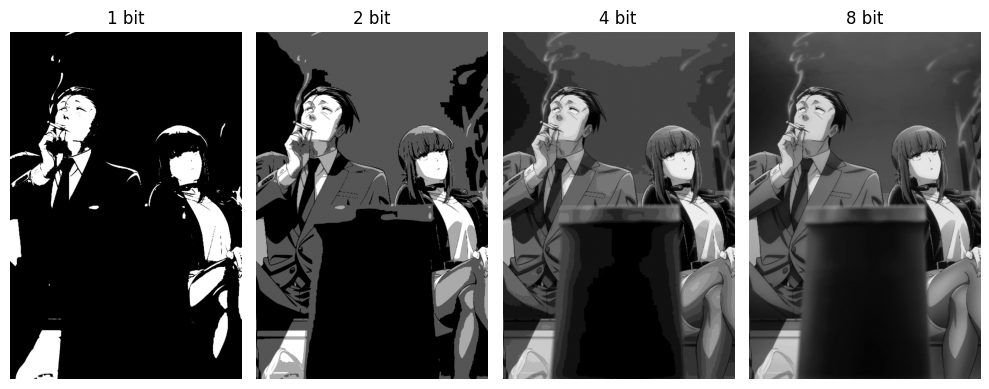

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(10,4))

ax[0].imshow(resultado, cmap='gray')
ax[0].set_title('1 bit')
ax[0].axis('off')

ax[1].imshow(resultado2,cmap='gray')
ax[1].set_title('2 bit')
ax[1].axis('off')

ax[2].imshow(resultado3,cmap='gray')
ax[2].set_title('4 bit')
ax[2].axis('off')

ax[3].imshow(resultado4, cmap='gray')
ax[3].set_title('8 bit')
ax[3].axis('off')

plt.tight_layout()
plt.savefig('Aula_conversao_de_cores.png')
plt.show()

O que acontece com os detalhes e com as transições de intensidade da imagem à medida que reduzimos o número de bits?

In [13]:
Podemos perceber que conforme reduzimos o número de bits, a imagem vai ficando menos detalhada, os tons de preto e branco vão se misturando, e transições começam a se fundir